# Практическая работа 5.2: Bagging classification | Heart Failure Prediction

Цель: построить и оценить ансамблевую модель бэггинга (`BaggingClassifier`) для задачи прогнозирования заболеваний сердца, проанализировать влияние соотношения обучающей и тестовой выборок и параметров ансамбля на качество классификации по метрикам `accuracy`, `precision`, `recall` и `F1`.

## 1. Импорты и конфигурация

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub

DATASET_HANDLE = "fedesoriano/heart-failure-prediction"
DATASET_FILE = "heart.csv"

TARGET_COL = "HeartDisease"

RANDOM_STATE = 42

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 5)
pd.set_option("display.max_columns", 120)


## 2. Описание данных

**Что это за данные:**
- `heart.csv` содержит клинические и инструментальные показатели пациентов.
- Цель: предсказать наличие заболевания сердца (`HeartDisease`).
- Размер: `918` наблюдений, `11` признаков + `1` целевая переменная.

**Источник:**
- Kaggle: `fedesoriano/heart-failure-prediction`.
- Подготовленный набор для задач бинарной классификации сердечно-сосудистого риска.

**Колонки:**
- `Age` — возраст пациента.
- `Sex` — пол (`M`, `F`).
- `ChestPainType` — тип боли в груди (`ATA`, `NAP`, `ASY`, `TA`).
- `RestingBP` — артериальное давление в покое.
- `Cholesterol` — уровень холестерина.
- `FastingBS` — признак повышенного сахара натощак (`1` если > 120 mg/dl, иначе `0`).
- `RestingECG` — результаты ЭКГ в покое.
- `MaxHR` — максимальная частота сердечных сокращений.
- `ExerciseAngina` — стенокардия, вызванная нагрузкой (`Y`/`N`).
- `Oldpeak` — депрессия сегмента ST относительно покоя.
- `ST_Slope` — наклон сегмента ST при нагрузке.
- `HeartDisease` — целевая переменная (`1` — заболевание есть, `0` — нет).


## 3. Загрузка датасета

In [2]:
def load_dataset(
    data_dir: Path,
    dataset_handle: str = DATASET_HANDLE,
    dataset_file: str = DATASET_FILE,
    sep: str = ",",
) -> pd.DataFrame:
    """Загружает датасет Heart Failure Prediction и возвращает его как DataFrame.

    Parameters
    ----------
    data_dir : Path
        Каталог, в который скачиваются файлы датасета.
    dataset_handle : str, default=DATASET_HANDLE
        Идентификатор датасета в Kaggle (`owner/dataset-name`).
    dataset_file : str, default=DATASET_FILE
        Имя CSV-файла, который необходимо прочитать после загрузки.
    sep : str, default=","
        Разделитель столбцов в исходном CSV-файле.

    Returns
    -------
    pd.DataFrame
        Загруженный датасет в табличном формате.
    """
    kagglehub.dataset_download(
        dataset_handle,
        output_dir=str(data_dir),
    )
    dataset_path = data_dir / dataset_file
    return pd.read_csv(dataset_path, sep=sep)


In [3]:
DATA_DIR = Path(".data")
DATA_DIR.mkdir(parents=True, exist_ok=True)
df = load_dataset(DATA_DIR)
df.head()


100%|██████████| 8.56k/8.56k [00:00<00:00, 14.0MB/s]

Extracting files...


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


## 4. Предобработка признаков

### 4.1. Преобразование признака `FastingBS` в категориальный

Поскольку в целочисленной переменной `FastingBS` всего 2 различных класса, то стоит определить ее как категориальную со строковым значением.

In [5]:
df_prepared = df.copy()
df_prepared["FastingBS"] = df_prepared["FastingBS"].map({0: "Yes", 1: "No"}).astype("str")


In [6]:
df_prepared.info()


<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    str    
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(5), str(6)
memory usage: 86.2 KB


## 5. Формирование `X`, `y`

In [7]:
def split_features_target(df: pd.DataFrame, target_col: str = TARGET_COL) -> tuple[pd.DataFrame, pd.Series]:
    """Разделяет подготовленный датасет на признаки и целевую переменную.

    Parameters
    ----------
    df : pd.DataFrame
        Подготовленный датасет.
    target_col : str, default=TARGET_COL
        Название целевой переменной.

    Returns
    -------
    tuple[pd.DataFrame, pd.Series]
        Матрица признаков `X` и бинаризованная целевая переменная `y`.
    """
    X = df.drop(columns=[target_col]).copy()
    y = df[target_col]
    return X, y


In [8]:
X, y = split_features_target(df_prepared)

overview = pd.DataFrame(
    {
        "Показатель": ["Количество объектов", "Количество признаков", "Доля класса True, %"],
        "Значение": [len(X), X.shape[1], round(y.mean() * 100, 2)],
    }
)

display(overview)


,Показатель,Значение
0,Количество объектов,918.00
1,Количество признаков,11.00
2,"Доля класса True, %",55.34


## 6. Построение пайплайна для классификатора

In [9]:
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


In [10]:
def build_preprocessor() -> ColumnTransformer:
    """Создает препроцессор для числовых и категориальных признаков.

    Returns
    -------
    ColumnTransformer
        Числовая ветка: медианная импутация + стандартизация.
        Категориальная ветка: импутация модой + one-hot кодирование.
    """
    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, make_column_selector(dtype_include=np.number)),
            ("cat", categorical_transformer, make_column_selector(dtype_exclude=np.number)),
        ]
    )


In [11]:
def build_pipeline(model_params: dict | None = None) -> Pipeline:
    """Формирует пайплайн предобработки и классификации

    Parameters
    ----------
    model_params : dict | None, default=None
        Словарь гиперпараметров для классификатора.
        Если передано `None`, используется пустой словарь и применяются
        параметры классификатора по умолчанию.

    Returns
    -------
    Pipeline
        Объединенный pipeline для обучения и предсказания.
    """
    if model_params is None:
        model_params = { "tree_params": {} }
    return Pipeline(
        steps=[
            ("preprocessor", build_preprocessor()),
            ("model", BaggingClassifier(random_state=RANDOM_STATE, **model_params)),
        ]
    )


## 7. Эксперименты

Экспериментальная часть выполняется на серии разбиений train/test с фиксированным шагом по доле обучающей выборки от `60%` до `90%`.

Для каждого сценария разбиения обучается `BaggingClassifier` с варьированием количества участников ансамбля `n_estimators` в диапазоне от `50` до `100` с шагом `10`.


In [12]:
def evaluate_estimator(
    X: pd.DataFrame,
    y: pd.Series,
    train_ratio: float,
    random_state: int,
    model_params: dict | None = None,
) -> dict:
    """Оценивает классификатор на одном train/test-сценарии.

    Parameters
    ----------
    X, y : pd.DataFrame, pd.Series
        Рабочий датасет без validation-части.
    train_ratio : float
        Доля train в паре train+test.
    random_state : int
        Seed воспроизводимости.
    model_params : dict | None, default=None
        Словарь гиперпараметров для классификатора.
        Если передано `None`, используется пустой словарь и применяются
        параметры классификатора по умолчанию.


    Returns
    -------
    dict
        Размеры выборок, параметры модели и метрики качества на test.
    """
    test_ratio = 1.0 - train_ratio

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        train_size=train_ratio,
        test_size=test_ratio,
        random_state=random_state,
        stratify=y,
    )

    pipeline = build_pipeline(model_params)
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_train_pred = pipeline.predict(X_train)

    result = {
        # train
        "train_ratio": train_ratio,
        "train_accuracy": accuracy_score(y_train, y_train_pred),
        "train_precision": precision_score(y_train, y_train_pred, zero_division=0),
        "train_recall": recall_score(y_train, y_train_pred, zero_division=0),
        "train_f1": f1_score(y_train, y_train_pred, zero_division=0),
        # test
        "test_ratio": test_ratio,
        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_precision": precision_score(y_test, y_pred, zero_division=0),
        "test_recall": recall_score(y_test, y_pred, zero_division=0),
        "test_f1": f1_score(y_test, y_pred, zero_division=0),
        "confusion_matrix": confusion_matrix(y_test, y_pred, labels=[0, 1]),
    }

    if model_params:
        result.update({ "model_params": model_params })

    return result


In [13]:
def run_experiments(
    X_model: pd.DataFrame,
    y_model: pd.Series,
    train_ratios: list[float],
    models_params: list[dict],
    random_state: int,
) -> pd.DataFrame:
    """Запускает серию train/test экспериментов`.

    Parameters
    ----------
    X_model, y_model : pd.DataFrame, pd.Series
        Рабочий набор без validation.
    train_ratios : list[float]
        Список долей train.
    random_state : int
        Seed воспроизводимости.
    models_params : dict | None, default=None
        Словарь гиперпараметров для классификаторов.

    Returns
    -------
    pd.DataFrame
        Таблица метрик по всем соотношениям train/test.
    """
    rows = []
    for model_params in models_params:
        for ratio in train_ratios:
            rows.append(
                evaluate_estimator(
                    X=X_model,
                    y=y_model,
                    train_ratio=ratio,
                    random_state=random_state,
                    model_params=model_params,
                )
            )

    results_df = pd.DataFrame(rows).reset_index(drop=True)
    return results_df


In [14]:
TRAIN_RATIOS = [round(x, 2) for x in np.arange(0.60, 0.95, 0.05)]
N_ESTIMATORS = [int(x) for x in np.arange(50, 110, 10)]
# CRITERIONS = ["entropy", "gini"]
# MAX_DEPTHS = [3, 5, 7, None]
# MIN_SAMPLES_LEAF = [1, 3, 5, 7]
# MIN_SAMPLES_SPLIT = [3, 5, 7]

MODELS_PARAMS = [
    {
        "n_estimators": n_estimators,
        "max_samples": 0.8,
        "max_features": 0.8,
        "estimator": DecisionTreeClassifier(
            criterion="entropy",
            max_depth=None,
            min_samples_leaf=1,
            min_samples_split=10,
            random_state=RANDOM_STATE,
        ),
    }
    for n_estimators in N_ESTIMATORS
    # for criterion in CRITERIONS
    # for max_depth in MAX_DEPTHS
    # for min_samples_leaf in MIN_SAMPLES_LEAF
    # for min_samples_split in MIN_SAMPLES_SPLIT
]


In [15]:
results_df = run_experiments(
    X_model=X,
    y_model=y,
    train_ratios=TRAIN_RATIOS,
    random_state=RANDOM_STATE,
    models_params=MODELS_PARAMS,
)

display(results_df)


,train_ratio,train_accuracy,train_precision,train_recall,train_f1,test_ratio,test_accuracy,test_precision,test_recall,test_f1,confusion_matrix,model_params
0,0.60,0.943636,0.920000,0.983553,0.950715,0.40,0.888587,0.889952,0.911765,0.900726,"[[141, 23], [18, 186]]","{'n_estimators': 50, 'max_samples': 0.8, 'max_..."
1,0.65,0.941275,0.930029,0.966667,0.947994,0.35,0.878882,0.879781,0.904494,0.891967,"[[122, 22], [17, 161]]","{'n_estimators': 50, 'max_samples': 0.8, 'max_..."
2,0.70,0.953271,0.940379,0.977465,0.958564,0.30,0.887681,0.881250,0.921569,0.900958,"[[104, 19], [12, 141]]","{'n_estimators': 50, 'max_samples': 0.8, 'max_..."
3,0.75,0.949128,0.939086,0.971129,0.954839,0.25,0.900000,0.893939,0.929134,0.911197,"[[89, 14], [9, 118]]","{'n_estimators': 50, 'max_samples': 0.8, 'max_..."
4,0.80,0.952316,0.942721,0.972906,0.957576,0.20,0.880435,0.877358,0.911765,0.894231,"[[69, 13], [9, 93]]","{'n_estimators': 50, 'max_samples': 0.8, 'max_..."
5,0.85,0.950000,0.939597,0.972222,0.955631,0.15,0.876812,0.864198,0.921053,0.891720,"[[51, 11], [6, 70]]","{'n_estimators': 50, 'max_samples': 0.8, 'max_..."
6,0.90,0.950363,0.938819,0.973742,0.955961,0.10,0.902174,0.920000,0.901961,0.910891,"[[37, 4], [5, 46]]","{'n_estimators': 50, 'max_samples': 0.8, 'max_..."
7,0.60,0.943636,0.922601,0.980263,0.950558,0.40,0.891304,0.894231,0.911765,0.902913,"[[142, 22], [18, 186]]","{'n_estimators': 60, 'max_samples': 0.8, 'max_..."
8,0.65,0.947987,0.941003,0.966667,0.953662,0.35,0.885093,0.881081,0.915730,0.898072,"[[122, 22], [15, 163]]","{'n_estimators': 60, 'max_samples': 0.8, 'max_..."
9,0.70,0.950156,0.932976,0.980282,0.956044,0.30,0.894928,0.892405,0.921569,0.906752,"[[106, 17], [12, 141]]","{'n_estimators': 60, 'max_samples': 0.8, 'max_..."


## 8. Визуализация результатов

In [16]:
def plot_metrics_by_ratio(results_df: pd.DataFrame) -> None:
    """Строит графики метрик по train_ratio с группировкой по model_params.

    Parameters
    ----------
    results_df : pd.DataFrame
        Таблица результатов экспериментов. Ожидаются колонки:
        `train_ratio`, `model_params`, `accuracy`, `precision`, `recall`, `f1`.

    Returns
    -------
    None
    """

    plot_df = results_df.copy()

    def _params_to_label(v) -> str:
        if isinstance(v, dict):
            if not v:
                return "default"
            return ", ".join(f"{k}={v[k]}" for k in sorted(v))
        if pd.isna(v):
            return "default"
        return str(v)

    plot_df["model_params_label"] = plot_df["model_params"].apply(_params_to_label)

    plot_df_train = plot_df.melt(
        id_vars=["train_ratio", "model_params_label"],
        value_vars=["train_accuracy", "train_precision", "train_recall", "train_f1"],
        var_name="metric",
        value_name="value",
    )

    plot_df_test = plot_df.melt(
        id_vars=["train_ratio", "model_params_label"],
        value_vars=["test_accuracy", "test_precision", "test_recall", "test_f1"],
        var_name="metric",
        value_name="value",
    )

    labels = plot_df["model_params_label"].unique()
    n_rows = len(labels)
    fig, axes = plt.subplots(n_rows, 2, figsize=(15, 4.5 * n_rows))
    axes = np.array(axes).reshape(n_rows, 2)

    for (ax_train, ax_test), label in zip(axes, labels):
        part_train = plot_df_train[plot_df_train["model_params_label"] == label]
        sns.lineplot(data=part_train, x="train_ratio", y="value", hue="metric", marker="o", ax=ax_train)
        ax_train.set_title(label)
        ax_train.set_xlabel("")
        ax_train.set_ylabel("")
        ax_train.set_ylim(0, 1)

        part_test = plot_df_test[plot_df_test["model_params_label"] == label]
        sns.lineplot(data=part_test, x="train_ratio", y="value", hue="metric", marker="o", ax=ax_test)
        ax_test.set_title(label)
        ax_test.set_xlabel("")
        ax_test.set_ylabel("")
        ax_test.set_ylim(0, 1)

    fig.suptitle("Метрики качества моделей", y=1.0, fontsize=16)
    fig.supxlabel("Доля train")
    fig.supylabel("Значение метрики")
    plt.tight_layout()
    plt.show()


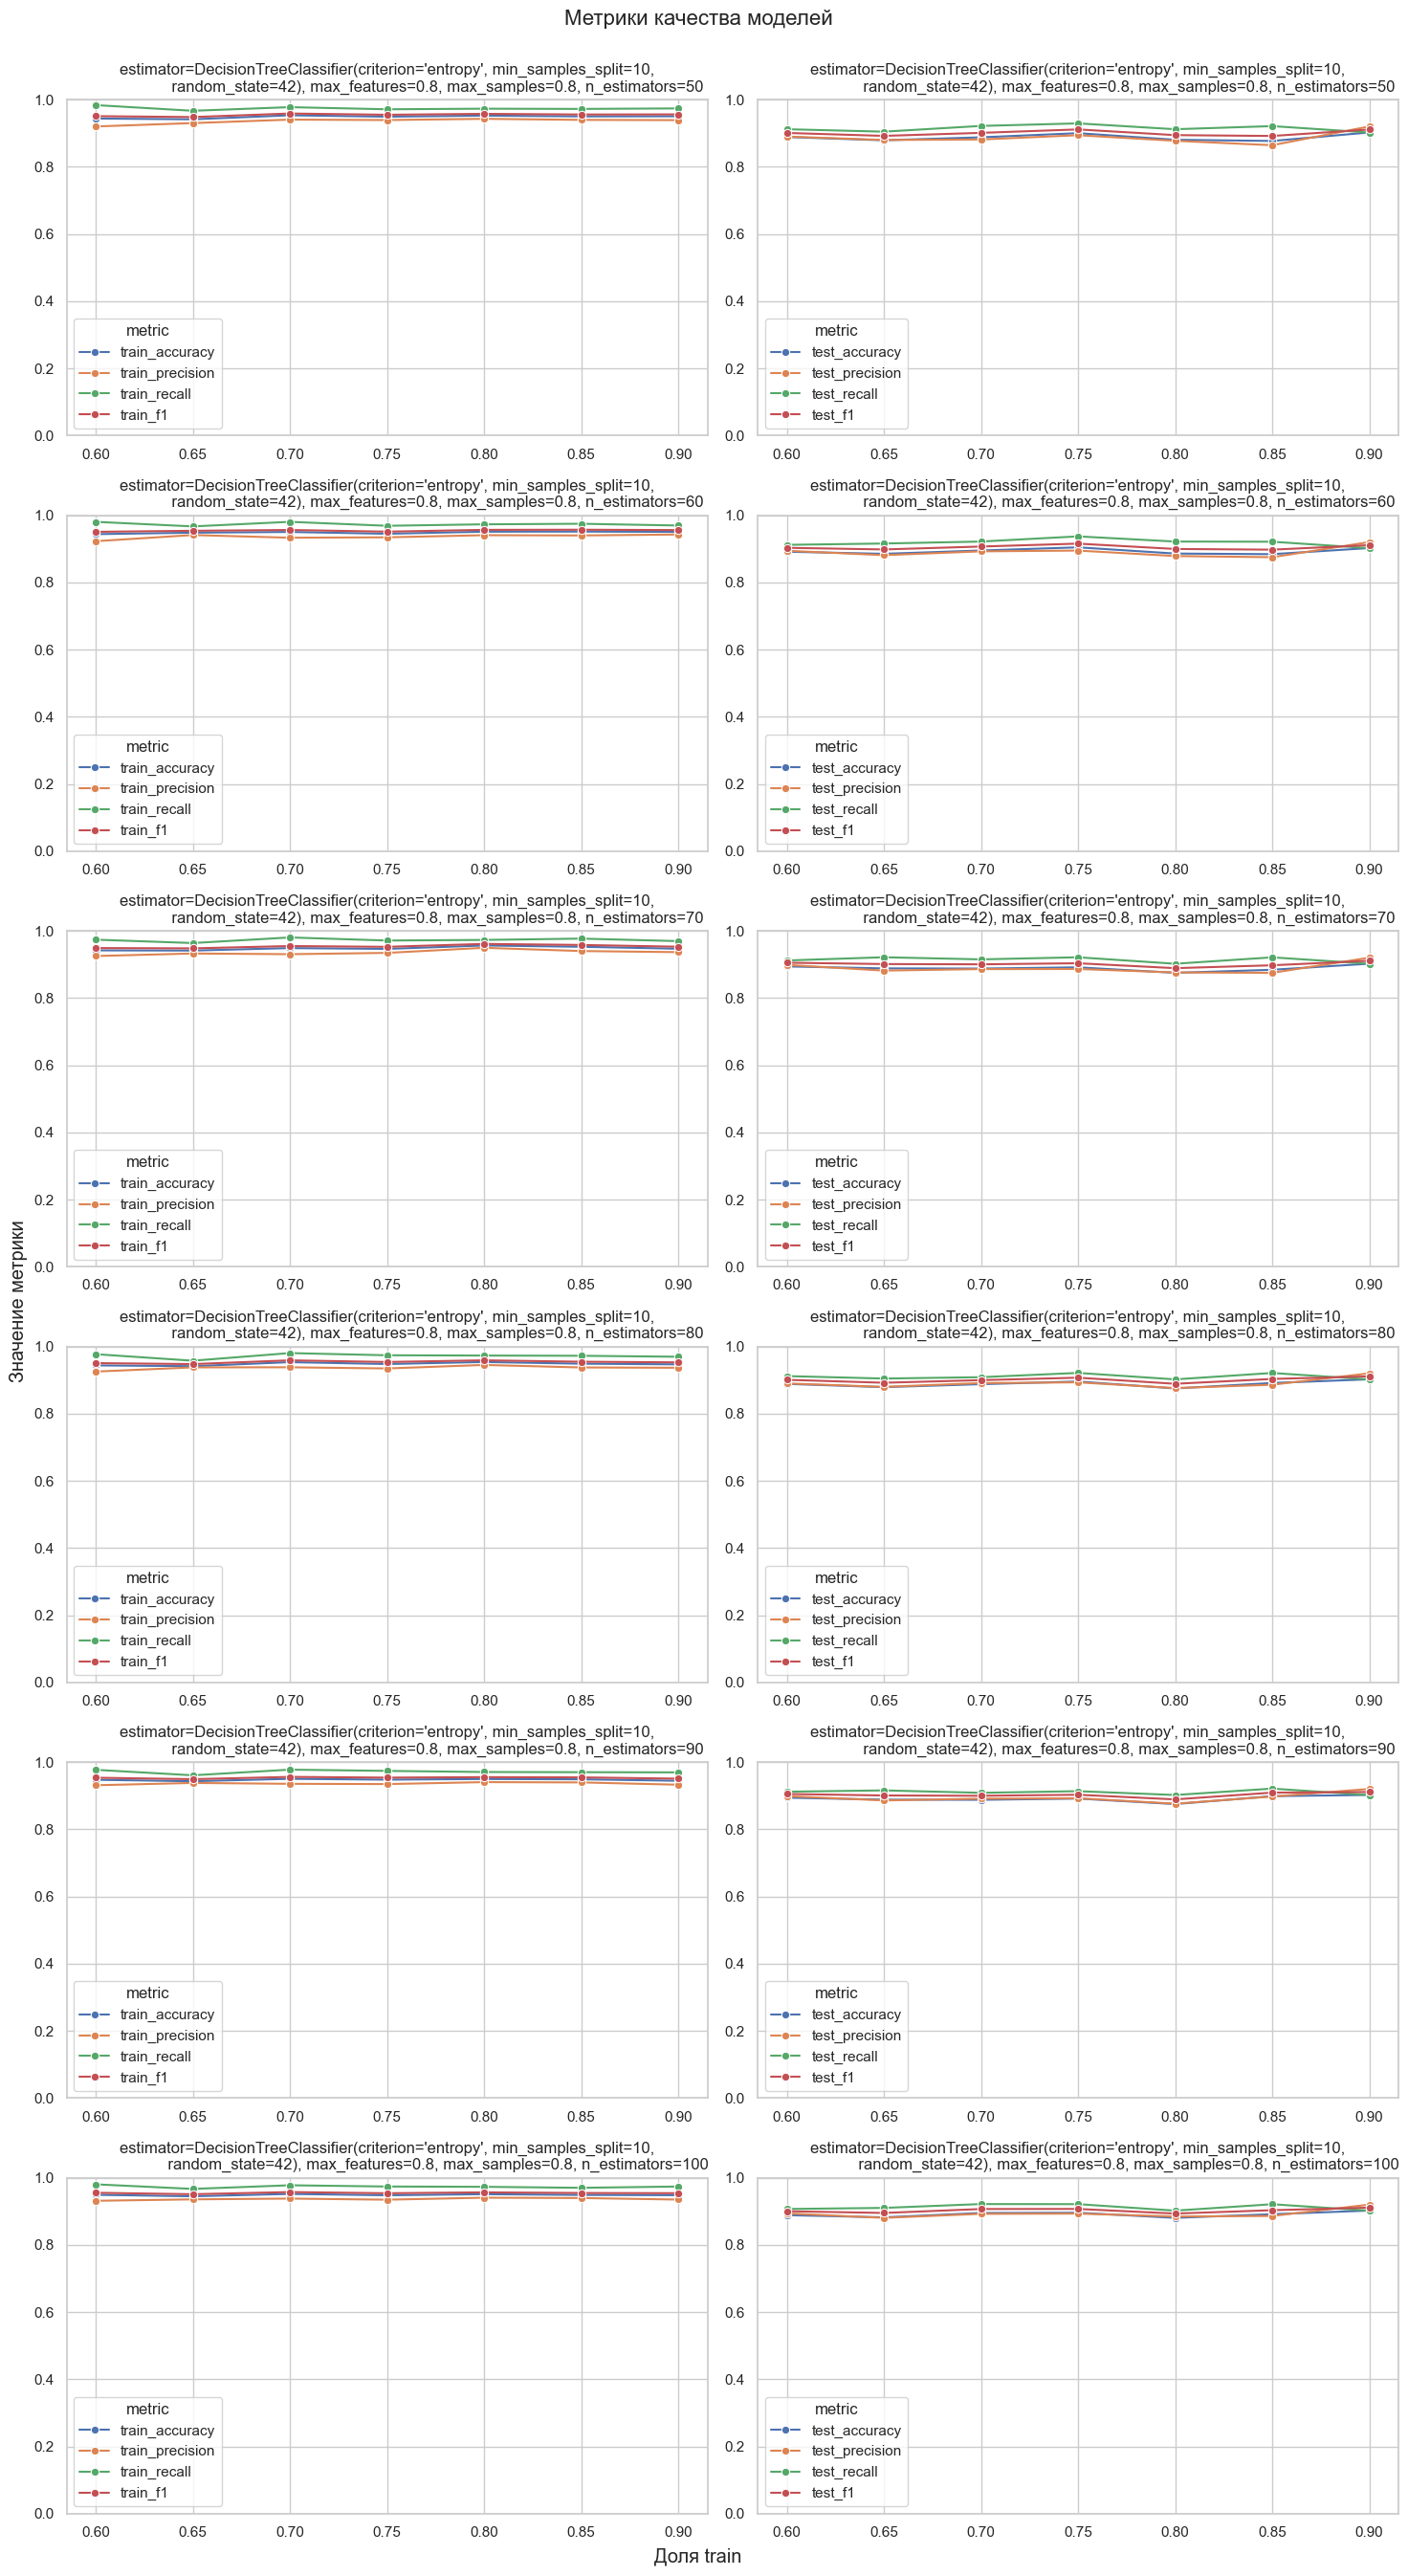

In [17]:
plot_metrics_by_ratio(results_df)


## 9. Визуализация лучшей конфигурации

In [18]:
def get_best_by_metric(results_df: pd.DataFrame, metric: str) -> pd.Series:
    """Возвращает лучший сценарий по выбранной метрике.

    Parameters
    ----------
    results_df : pd.DataFrame
        Таблица результатов train/test экспериментов.
    metric : str
        Метрика выбора лучшего сценария.

    Returns
    -------
    pd.Series
        Строка с лучшей конфигурацией.
    """
    best_idx = results_df[metric].idxmax()
    return results_df.loc[best_idx]


In [19]:
def plot_confusion_matrix(row: pd.Series) -> None:
    """Строит confusion matrix для одного сценария эксперимента.

    Parameters
    ----------
    row : pd.Series
        Строка результатов эксперимента, содержащая значение `cm`.

    Returns
    -------
    None
        Функция отображает тепловую карту матрицы ошибок.
    """

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        row["confusion_matrix"],
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No disease (0)", "Disease (1)"],
        yticklabels=["No disease (0)", "Disease (1)"],
    )
    plt.title("Матрица ошибок")
    plt.xlabel("Предсказанный класс")
    plt.ylabel("Истинный класс")
    plt.tight_layout()
    plt.show()


In [20]:
best_row = get_best_by_metric(results_df, metric="test_f1")
display(best_row.to_frame(name="value").drop(["confusion_matrix"], axis=0))


,value
train_ratio,0.75
train_accuracy,0.944767
train_precision,0.934177
train_recall,0.968504
train_f1,0.951031
test_ratio,0.25
test_accuracy,0.904348
test_precision,0.894737
test_recall,0.937008
test_f1,0.915385


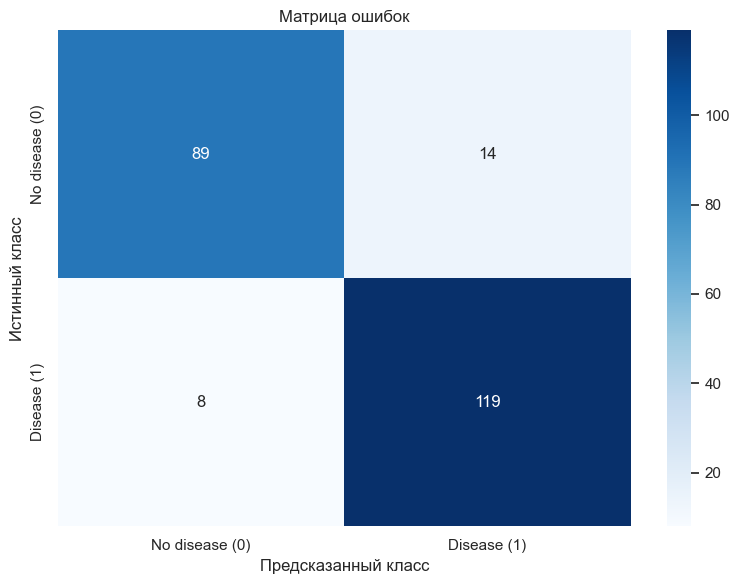

In [21]:
plot_confusion_matrix(best_row)


## 10. Вывод

В ходе работы выполнено обучение и сравнительная оценка модели `BaggingClassifier` на наборе данных Heart Failure Prediction при варьировании соотношения train/test в диапазоне от `60:40` до `90:10`.

Исследовано влияние параметра `n_estimators` в диапазоне от `50` до `100` с шагом `10`.
